

# Predictive Analytics — Exploratory Data Analysis
**Project:** Sentiment Classification (Positive / Neutral / Negative)  
**Dataset:** Yelp Review Full (10,000 sample)  
**Goal:** Understand feature distributions, class balance, correlations, and outliers before model training.



#  1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
from datasets import load_dataset
import nltk
from nltk.tokenize import sent_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('punkt', quiet=True)
nltk.download('vader_lexicon', quiet=True)

warnings.filterwarnings('ignore')

PALETTE = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('Setup complete ✓')

Setup complete ✓


# 2. Load Data & Feature Engineering

In [2]:
# Load dataset
dataset = load_dataset('yelp_review_full')
df = dataset['train'].to_pandas()[['text', 'label']].sample(n=10000, random_state=42).reset_index(drop=True)
df['stars'] = df['label'] + 1

# Target variable
def rating_to_sentiment(r):
    if r >= 4:   return 'Positive'
    elif r == 3: return 'Neutral'
    else:        return 'Negative'

df['sentiment'] = df['stars'].apply(rating_to_sentiment)

# Basic text cleaning
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s!?.,\'"\-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

# ── Engineered Features (input to predictive model) ──────────────────────────
sia = SentimentIntensityAnalyzer()
nltk.download('punkt_tab', quiet=True)

df['word_count']           = df['clean_text'].str.split().str.len()
df['char_count']           = df['clean_text'].str.len()
df['sent_count']           = df['text'].apply(lambda x: len(sent_tokenize(str(x))))
df['avg_word_len']         = df['clean_text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
df['vader_compound']       = df['clean_text'].apply(lambda t: sia.polarity_scores(t)['compound'])
df['vader_pos']            = df['clean_text'].apply(lambda t: sia.polarity_scores(t)['pos'])
df['vader_neg']            = df['clean_text'].apply(lambda t: sia.polarity_scores(t)['neg'])
df['vader_neu']            = df['clean_text'].apply(lambda t: sia.polarity_scores(t)['neu'])
df['exclamation_count']    = df['clean_text'].str.count('!')
df['question_count']       = df['clean_text'].str.count('\?')
df['exclamation_density']  = df['exclamation_count'] / (df['word_count'] + 1)
df['caps_ratio']           = df['text'].apply(
    lambda t: sum(1 for c in t if c.isupper()) / (len(t) + 1))
df['unique_word_ratio']    = df['clean_text'].apply(
    lambda t: len(set(t.split())) / (len(t.split()) + 1))
df['review_len_extreme']   = ((df['word_count'] < 5) | (df['word_count'] > 300)).astype(int)

print(f'Dataset loaded: {len(df):,} rows')
print(f'Features engineered: {df.shape[1]} columns total')
df.head(3)


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset loaded: 10,000 rows
Features engineered: 19 columns total


,text,label,stars,sentiment,clean_text,word_count,char_count,sent_count,avg_word_len,vader_compound,vader_pos,vader_neg,vader_neu,exclamation_count,question_count,exclamation_density,caps_ratio,unique_word_ratio,review_len_extreme
0,"First of all i'm not a big fan of buffet, i tr...",0,1,Negative,"first of all i'm not a big fan of buffet, i tr...",62,308,3,3.983871,0.4229,0.123,0.080,0.796,0,0,0.000,0.025806,0.793651,0
1,Thanks Yelp. I was looking for the words to de...,1,2,Negative,thanks yelp. i was looking for the words to de...,199,1056,12,4.311558,0.9645,0.144,0.057,0.799,3,0,0.015,0.041276,0.650000,0
2,Service was so-so. They were receiving a deliv...,2,3,Neutral,service was so-so. they were receiving a deliv...,39,193,4,3.974359,0.6705,0.136,0.000,0.864,0,0,0.000,0.041237,0.800000,0


# 3. Dataset Overview

In [3]:
print('=== SHAPE ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== DATA TYPES ===')
print(df.dtypes)

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values ✓')

print('\n=== DUPLICATE ROWS ===')
print(f'Duplicates: {df.duplicated().sum()}')

print('\n=== NUMERICAL FEATURE SUMMARY ===')
FEATURE_COLS = ['word_count','char_count','sent_count','avg_word_len',
                'vader_compound','vader_pos','vader_neg','vader_neu',
                'exclamation_density','caps_ratio','unique_word_ratio']
df[FEATURE_COLS].describe().round(3)

=== SHAPE ===
Rows: 10,000  |  Columns: 19

=== DATA TYPES ===
text                    object
label                    int64
stars                    int64
sentiment               object
clean_text              object
word_count               int64
char_count               int64
sent_count               int64
avg_word_len           float64
vader_compound         float64
vader_pos              float64
vader_neg              float64
vader_neu              float64
exclamation_count        int64
question_count           int64
exclamation_density    float64
caps_ratio             float64
unique_word_ratio      float64
review_len_extreme       int64
dtype: object

=== MISSING VALUES ===
No missing values ✓

=== DUPLICATE ROWS ===
Duplicates: 0

=== NUMERICAL FEATURE SUMMARY ===


,word_count,char_count,sent_count,avg_word_len,vader_compound,vader_pos,vader_neg,vader_neu,exclamation_density,caps_ratio,unique_word_ratio
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,132.858,716.738,8.467,4.455,0.517,0.165,0.059,0.777,0.015,0.029,0.743
std,124.314,669.805,6.990,0.434,0.629,0.111,0.062,0.103,0.046,0.020,0.105
min,1.000,5.000,1.000,2.667,-0.998,0.000,0.000,0.000,0.000,0.000,0.371
25%,51.000,276.000,4.000,4.200,0.263,0.088,0.011,0.728,0.000,0.019,0.670
50%,97.000,521.000,6.000,4.400,0.858,0.146,0.045,0.791,0.000,0.025,0.744
75%,172.000,925.000,11.000,4.631,0.963,0.218,0.085,0.843,0.014,0.033,0.821
max,998.000,4994.000,72.000,9.000,1.000,0.867,1.000,1.000,1.500,0.500,0.982


# 4. Target Variable — Class Distribution

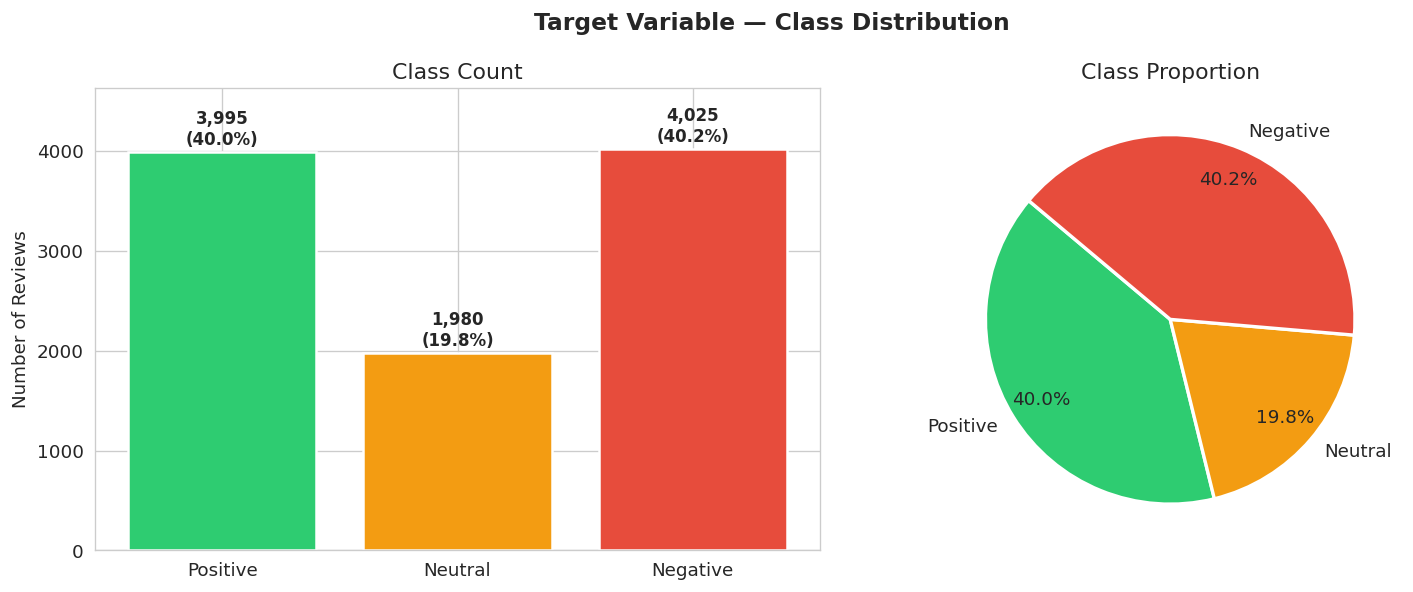


Class counts:
sentiment
Positive    3995
Neutral     1980
Negative    4025

Imbalance ratio (max/min): 2.03x
⚠️  Class imbalance detected — consider class_weight="balanced" or SMOTE during modeling.


In [4]:
sent_counts = df['sentiment'].value_counts().reindex(['Positive', 'Neutral', 'Negative'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Target Variable — Class Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(sent_counts.index, sent_counts.values,
                   color=[PALETTE[s] for s in sent_counts.index],
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Class Count')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_ylim(0, sent_counts.max() * 1.15)

# Pie chart
axes[1].pie(sent_counts.values, labels=sent_counts.index,
            colors=[PALETTE[s] for s in sent_counts.index],
            autopct='%1.1f%%', startangle=140, pctdistance=0.82,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', bbox_inches='tight')
plt.show()

# Imbalance warning
imbalance_ratio = sent_counts.max() / sent_counts.min()
print(f'\nClass counts:\n{sent_counts.to_string()}')
print(f'\nImbalance ratio (max/min): {imbalance_ratio:.2f}x')
if imbalance_ratio > 1.5:
    print('⚠️  Class imbalance detected — consider class_weight="balanced" or SMOTE during modeling.')

#5. Feature Distributions by Class

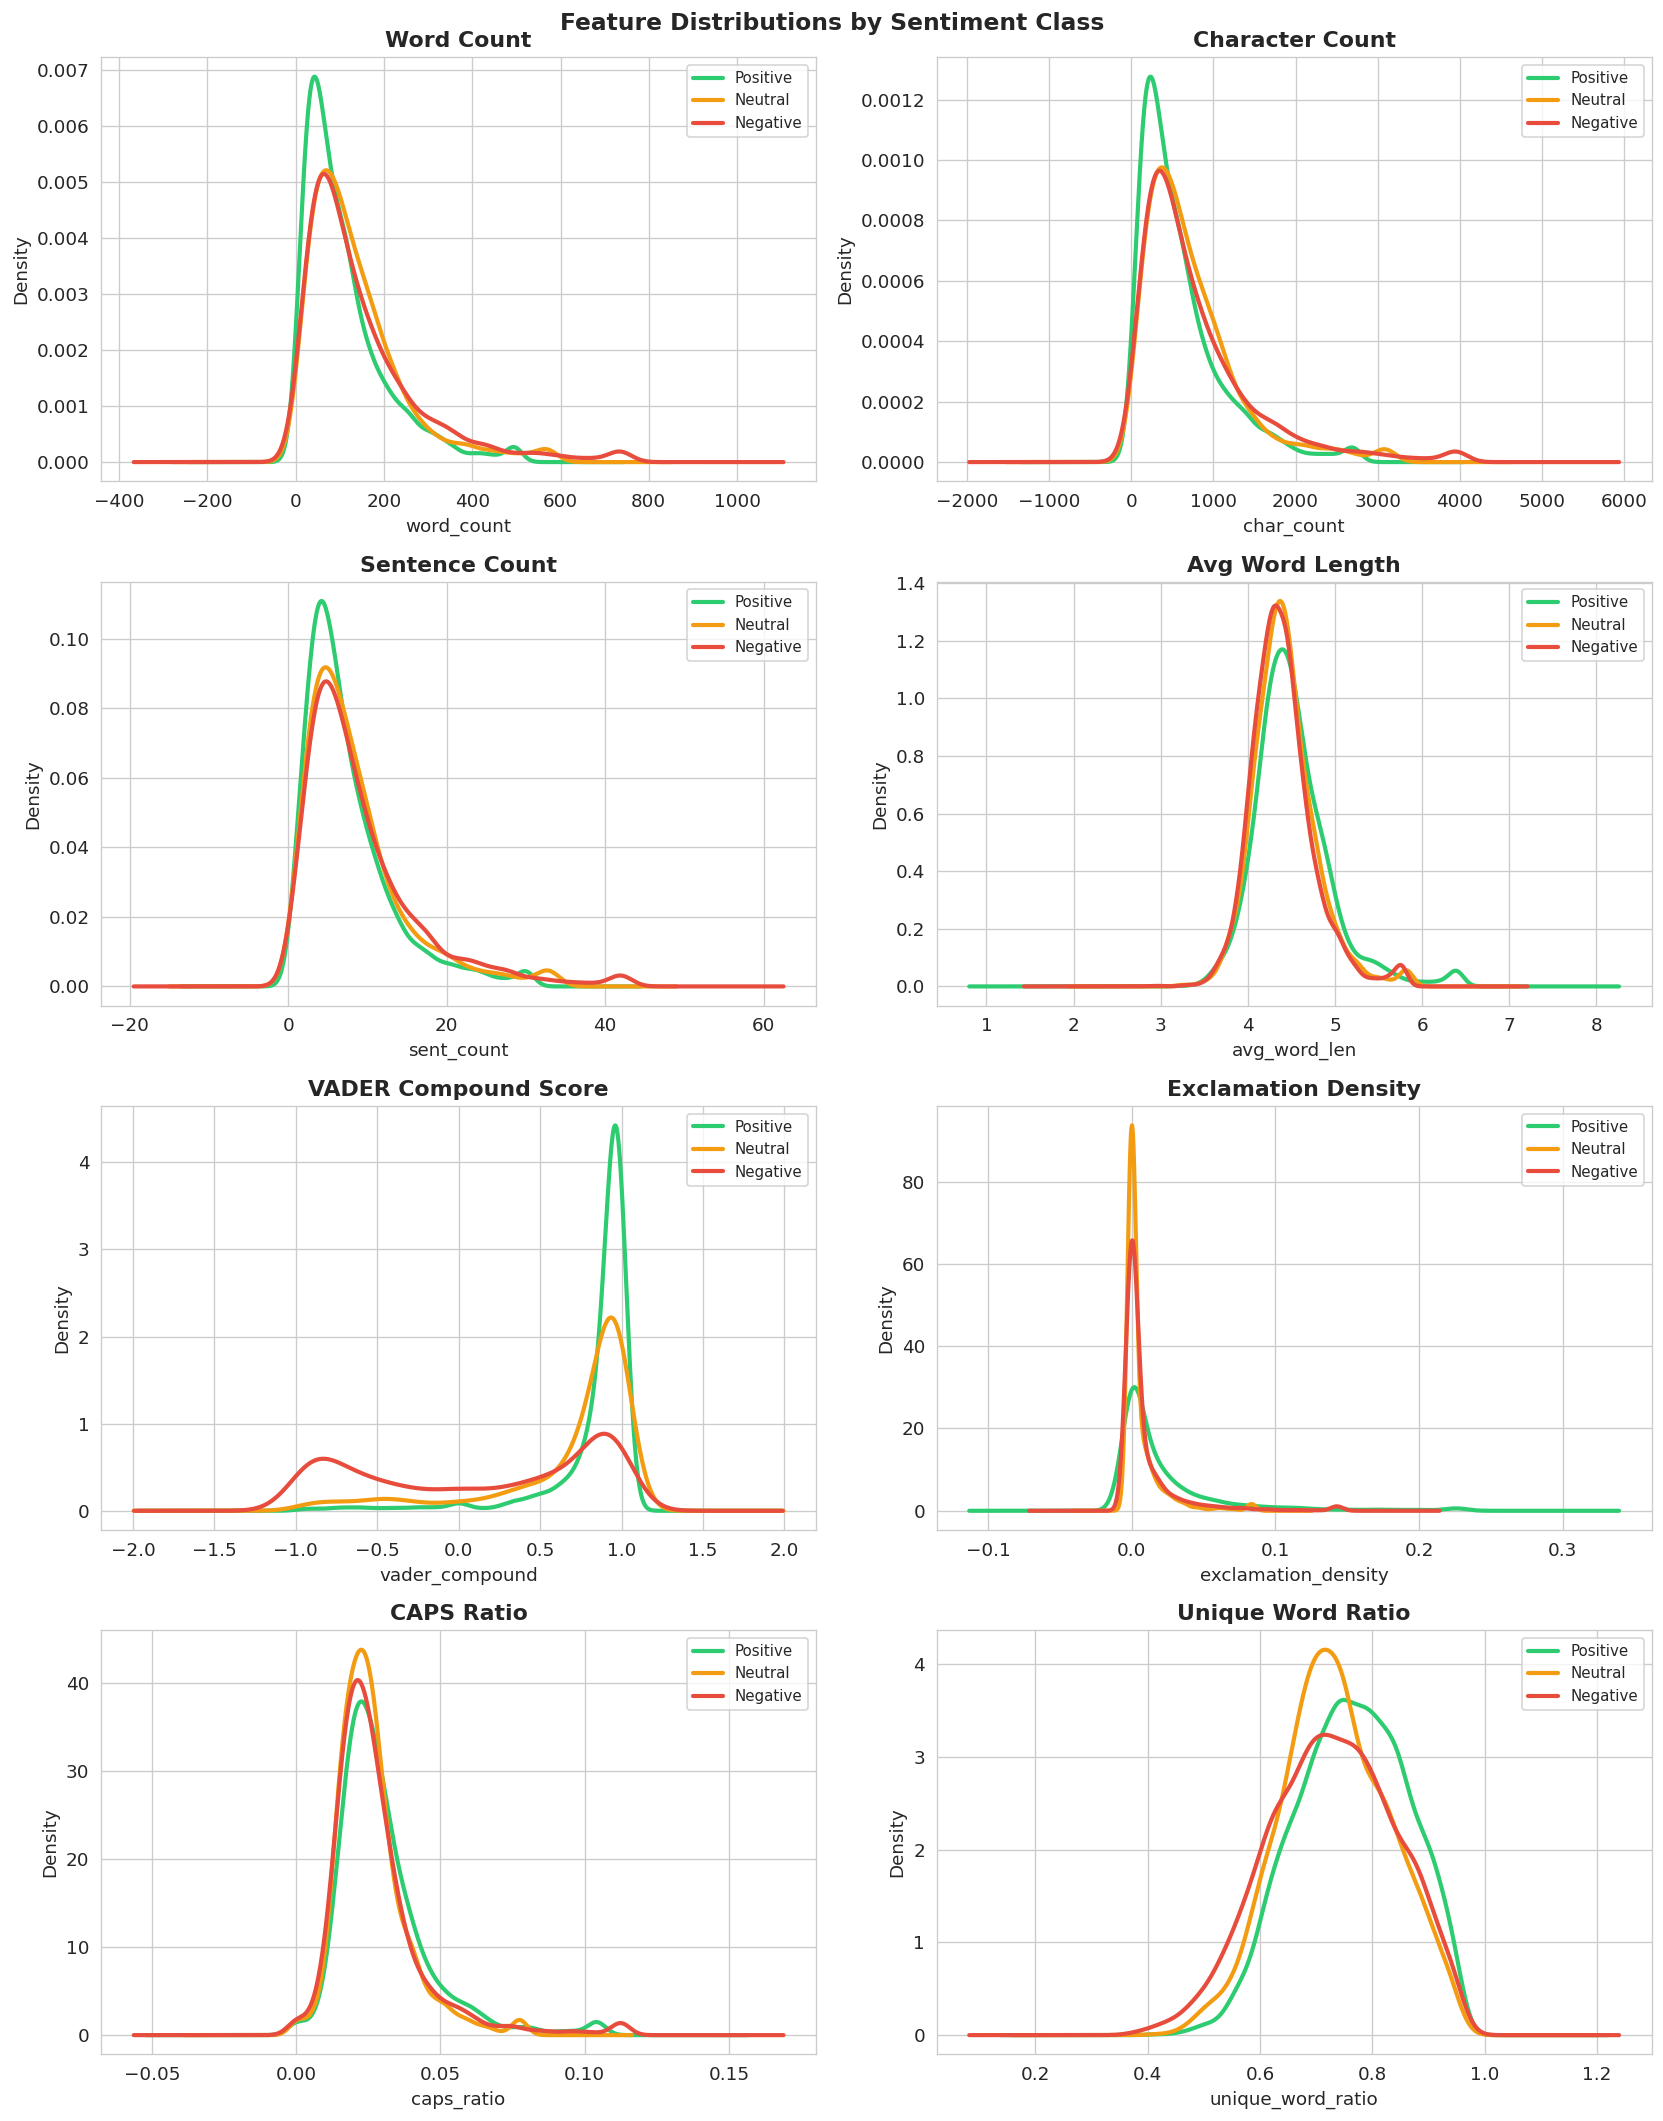

In [5]:
plot_features = [
    ('word_count',          'Word Count'),
    ('char_count',          'Character Count'),
    ('sent_count',          'Sentence Count'),
    ('avg_word_len',        'Avg Word Length'),
    ('vader_compound',      'VADER Compound Score'),
    ('exclamation_density', 'Exclamation Density'),
    ('caps_ratio',          'CAPS Ratio'),
    ('unique_word_ratio',   'Unique Word Ratio'),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
fig.suptitle('Feature Distributions by Sentiment Class', fontsize=14, fontweight='bold')

for ax, (col, title) in zip(axes.flat, plot_features):
    for sent in ['Positive', 'Neutral', 'Negative']:
        subset = df[df['sentiment'] == sent][col]
        clip_val = subset.quantile(0.99)
        subset.clip(upper=clip_val).plot.kde(
            ax=ax, label=sent, color=PALETTE[sent], linewidth=2.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_feature_distributions.png', bbox_inches='tight')
plt.show()

# 6. Feature Statistics by Class (Grouped)

In [6]:
group_stats = df.groupby('sentiment')[FEATURE_COLS].agg(['mean', 'median', 'std']).round(3)
print('=== Feature Statistics by Sentiment Class ===')
display(group_stats)

=== Feature Statistics by Sentiment Class ===


word_count                 char_count                 sent_count  \
                mean median      std       mean median      std       mean   
sentiment                                                                    
Negative     151.531  108.0  143.026    810.524  579.0  763.043      9.320   
Neutral      137.457  108.0  115.187    742.141  580.0  626.501      8.508   
Positive     111.766   82.0  103.430    609.657  441.0  566.944      7.587   

                        avg_word_len  ... vader_neu exclamation_density  \
          median    std         mean  ...       std                mean   
sentiment                             ...                                 
Negative     7.0  7.895        4.404  ...     0.086               0.011   
Neutral      7.0  6.759        4.429  ...     0.089               0.007   
Positive     6.0  5.950        4.519  ...     0.112               0.024   

                        caps_ratio               unique_word_ratio         \
          median    std       mean median    std              mean median   
sentiment                                                                   
Negative   0.000  0.044      0.029  0.024  0.023             0.727  0.728   
Neutral    0.000  0.022      0.027  0.024  0.016             0.733  0.729   
Positive   0.006  0.055      0.031  0.026  0.019             0.763  0.765   

                  
             std  
sentiment         
Negative   0.112  
Neutral    0.097  
Positive   0.098  

[3 rows x 33 columns]

#7. Boxplots — Outlier Detection

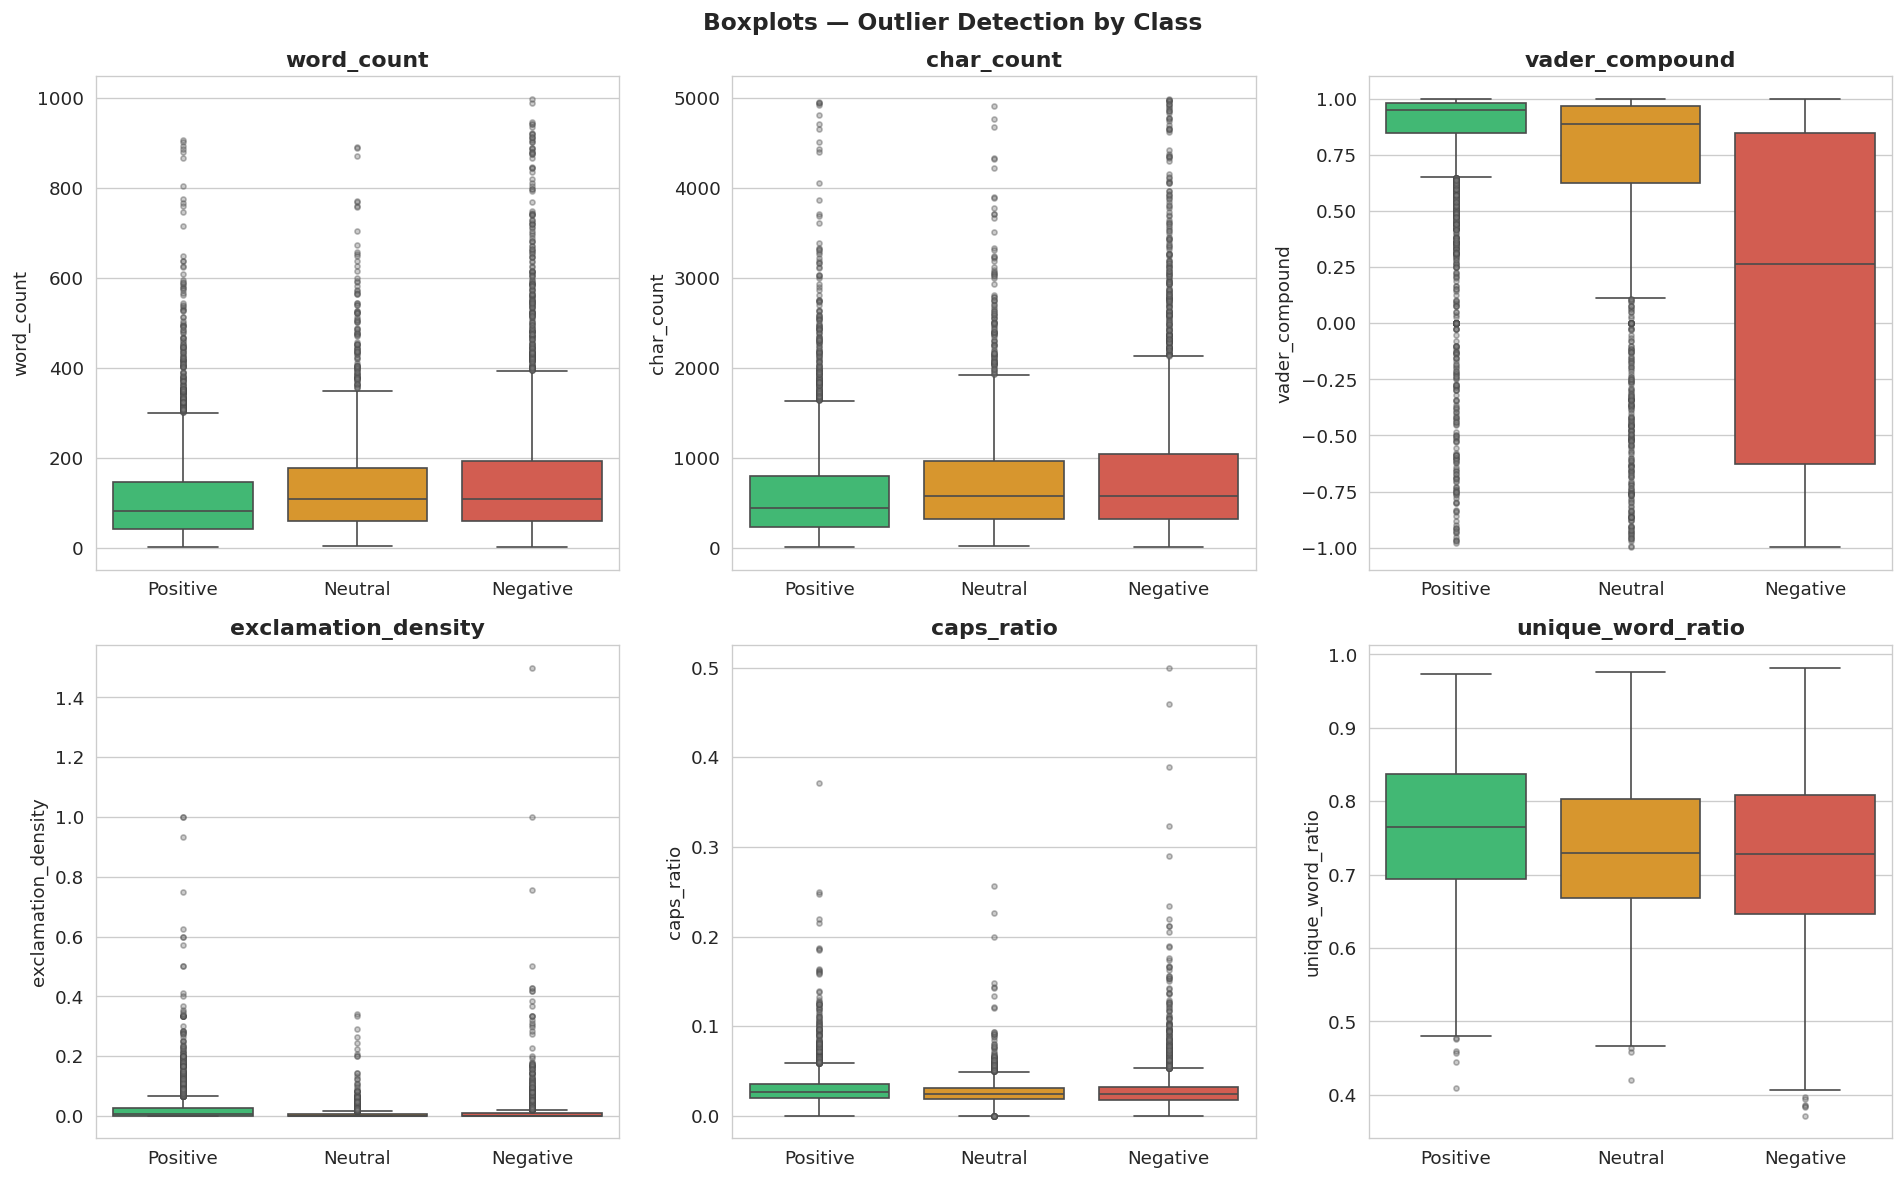


=== IQR Outlier Count per Feature ===
  word_count                Outliers:  555  (5.5%)
  char_count                Outliers:  567  (5.7%)
  vader_compound            Outliers:  755  (7.5%)
  exclamation_density       Outliers: 1121  (11.2%)
  caps_ratio                Outliers:  611  (6.1%)
  unique_word_ratio         Outliers:   28  (0.3%)


In [7]:
box_features = ['word_count', 'char_count', 'vader_compound', 'exclamation_density', 'caps_ratio', 'unique_word_ratio']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Boxplots — Outlier Detection by Class', fontsize=14, fontweight='bold')

order = ['Positive', 'Neutral', 'Negative']
for ax, col in zip(axes.flat, box_features):
    sns.boxplot(
        data=df, x='sentiment', y=col, order=order,
        palette=PALETTE, ax=ax,
        flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'markersize': 3, 'alpha': 0.4}
    )
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('eda_boxplots.png', bbox_inches='tight')
plt.show()

# IQR-based outlier count per feature
print('\n=== IQR Outlier Count per Feature ===')
for col in box_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:<25} Outliers: {n_out:>4}  ({n_out/len(df)*100:.1f}%)')

#8. Correlation Heatmap

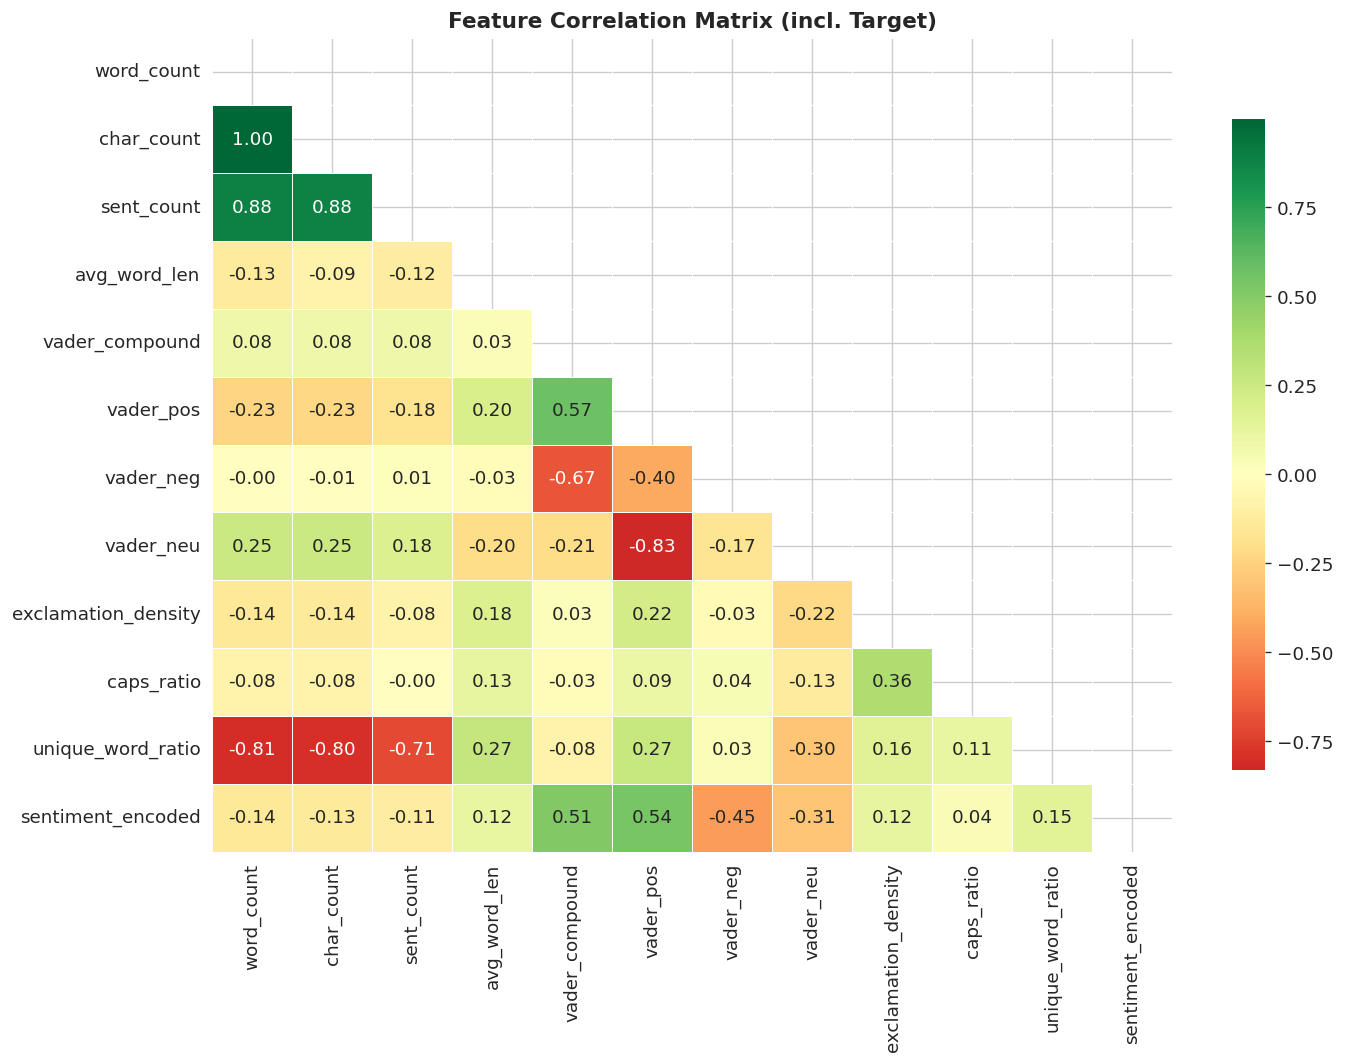


=== Feature Correlation with Target (sentiment_encoded) ===
vader_pos              0.536
vader_compound         0.511
vader_neg             -0.447
vader_neu             -0.306
unique_word_ratio      0.154
word_count            -0.143
char_count            -0.134
exclamation_density    0.122
avg_word_len           0.119
sent_count            -0.111
caps_ratio             0.040


In [8]:
# Encode target for correlation
label_map = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
df['sentiment_encoded'] = df['sentiment'].map(label_map)

corr_cols = FEATURE_COLS + ['sentiment_encoded']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (incl. Target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()

# Top correlated features with target
print('\n=== Feature Correlation with Target (sentiment_encoded) ===')
target_corr = corr['sentiment_encoded'].drop('sentiment_encoded').sort_values(key=abs, ascending=False)
print(target_corr.round(3).to_string())

#9. Pairplot — Key Features

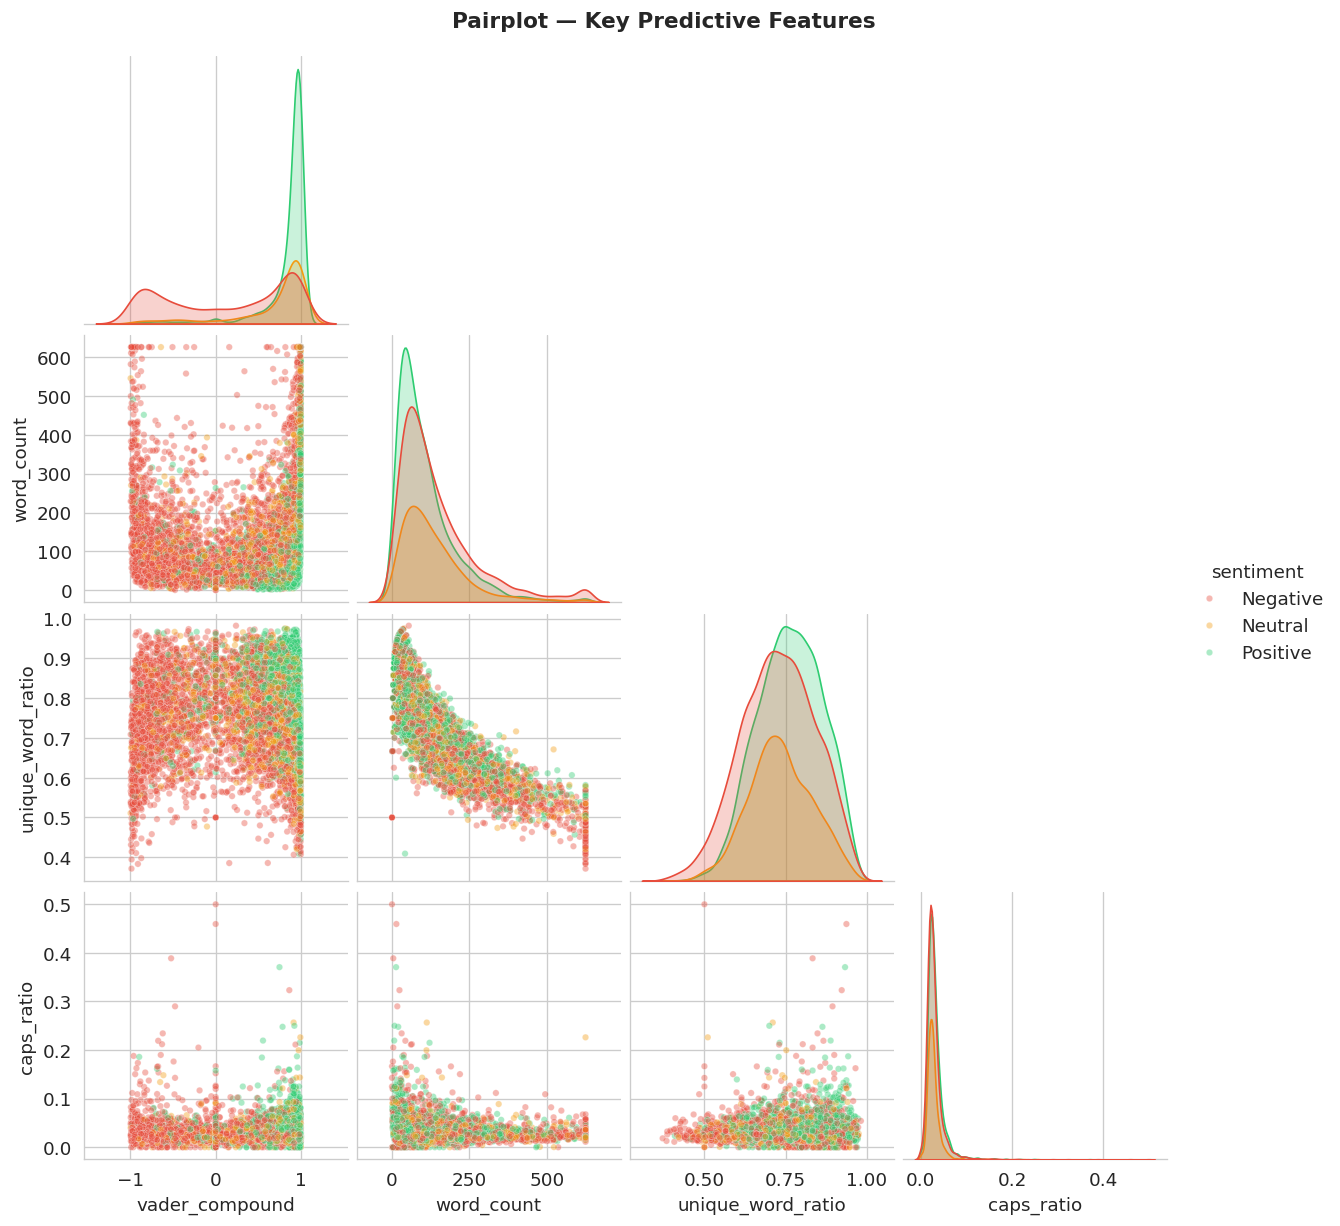

In [9]:
pairplot_cols = ['vader_compound', 'word_count', 'unique_word_ratio', 'caps_ratio', 'sentiment']
pair_df = df[pairplot_cols].copy()

# Clip extreme values for cleaner plot
for col in ['word_count']:
    pair_df[col] = pair_df[col].clip(upper=pair_df[col].quantile(0.99))

g = sns.pairplot(pair_df, hue='sentiment', palette=PALETTE,
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde', corner=True)
g.figure.suptitle('Pairplot — Key Predictive Features', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('eda_pairplot.png', bbox_inches='tight')
plt.show()

#10. VADER Score vs Star Rating — Baseline Alignment

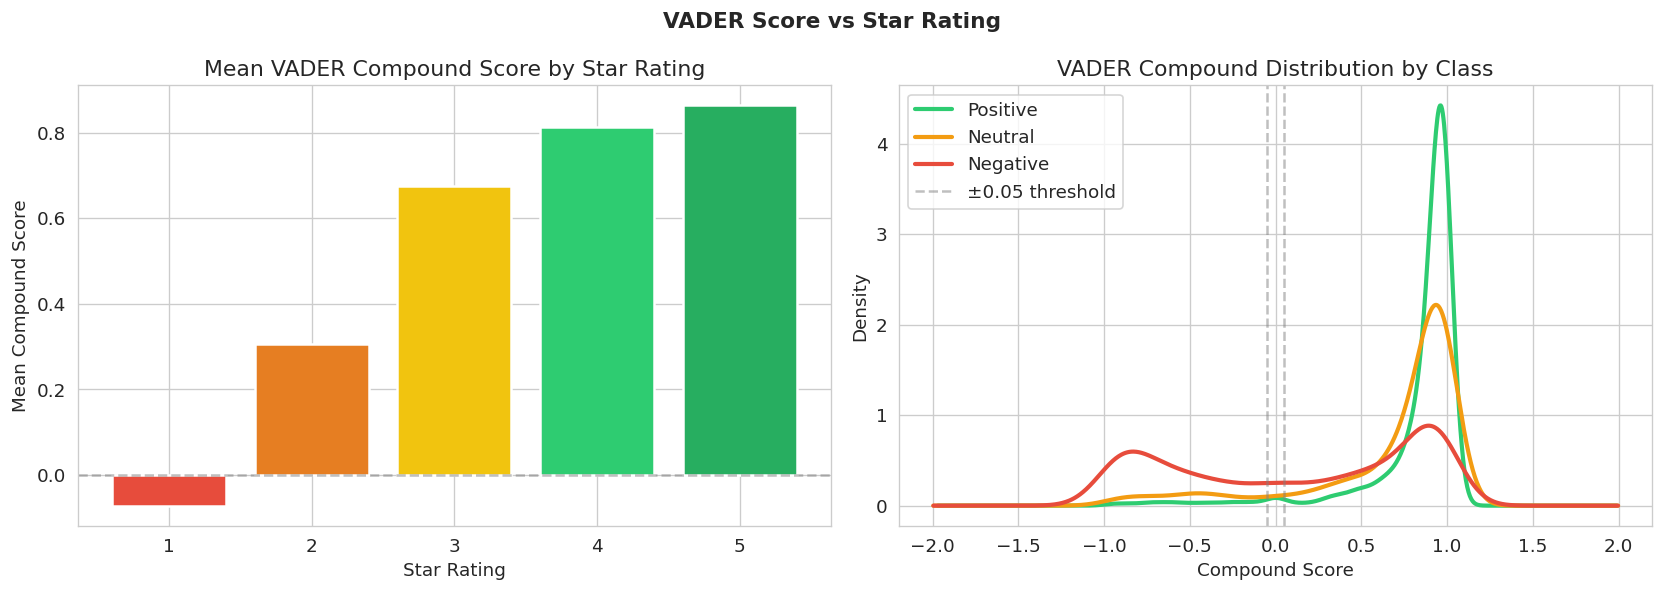

Insight: vader_compound separates Positive vs Negative well — strong predictive feature.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VADER Score vs Star Rating', fontsize=13, fontweight='bold')

# Mean VADER compound by star
mean_vader = df.groupby('stars')['vader_compound'].mean()
axes[0].bar(mean_vader.index, mean_vader.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Mean VADER Compound Score by Star Rating')
axes[0].set_xlabel('Star Rating'); axes[0].set_ylabel('Mean Compound Score')
axes[0].axhline(0, ls='--', color='gray', alpha=0.5)

# VADER compound distribution per class
for sent in ['Positive', 'Neutral', 'Negative']:
    df[df['sentiment'] == sent]['vader_compound'].plot.kde(
        ax=axes[1], label=sent, color=PALETTE[sent], linewidth=2.5)
axes[1].axvline(0.05, ls='--', color='gray', alpha=0.5, label='±0.05 threshold')
axes[1].axvline(-0.05, ls='--', color='gray', alpha=0.5)
axes[1].set_title('VADER Compound Distribution by Class')
axes[1].set_xlabel('Compound Score'); axes[1].legend()

plt.tight_layout()
plt.savefig('eda_vader_alignment.png', bbox_inches='tight')
plt.show()

print('Insight: vader_compound separates Positive vs Negative well — strong predictive feature.')

#11. EDA Summary

In [11]:
print('=' * 60)
print('         PREDICTIVE ANALYTICS EDA — SUMMARY')
print('=' * 60)

print(f'\n📦 Dataset       : {len(df):,} reviews, {len(FEATURE_COLS)} predictive features')
print(f'🎯 Target        : sentiment (Positive / Neutral / Negative)')
print(f'❓ Missing values: {df[FEATURE_COLS].isnull().sum().sum()}')
print(f'🔁 Duplicates    : {df.duplicated().sum()}')

print('\n📊 Class Distribution:')
for sent, count in df['sentiment'].value_counts().items():
    print(f'   {sent:<10}: {count:,}  ({count/len(df)*100:.1f}%)')

print('\n🔗 Top Features Correlated with Target:')
top_corr = corr['sentiment_encoded'].drop('sentiment_encoded').abs().sort_values(ascending=False).head(5)
for feat, val in top_corr.items():
    print(f'   {feat:<25}: {val:.3f}')

print('\n⚠️  Modeling Notes:')
if imbalance_ratio > 1.5:
    print('   - Class imbalance present → use class_weight="balanced"')
print('   - Outliers detected in word_count & exclamation_density → consider clipping')
print('   - vader_compound is strongest individual predictor')
print('   - vader_pos / vader_neg / vader_neu are correlated → may cause multicollinearity')
print('=' * 60)

         PREDICTIVE ANALYTICS EDA — SUMMARY

📦 Dataset       : 10,000 reviews, 11 predictive features
🎯 Target        : sentiment (Positive / Neutral / Negative)
❓ Missing values: 0
🔁 Duplicates    : 0

📊 Class Distribution:
   Negative  : 4,025  (40.2%)
   Positive  : 3,995  (40.0%)
   Neutral   : 1,980  (19.8%)

🔗 Top Features Correlated with Target:
   vader_pos                : 0.536
   vader_compound           : 0.511
   vader_neg                : 0.447
   vader_neu                : 0.306
   unique_word_ratio        : 0.154

⚠️  Modeling Notes:
   - Class imbalance present → use class_weight="balanced"
   - Outliers detected in word_count & exclamation_density → consider clipping
   - vader_compound is strongest individual predictor
   - vader_pos / vader_neg / vader_neu are correlated → may cause multicollinearity


#12. Save Preprocessed Data

In [12]:
save_cols = [
    'clean_text', 'stars', 'sentiment',
    'word_count', 'char_count', 'sent_count', 'avg_word_len',
    'vader_compound', 'vader_pos', 'vader_neg', 'vader_neu',
    'exclamation_count', 'question_count', 'exclamation_density',
    'caps_ratio', 'unique_word_ratio', 'review_len_extreme'
]

df[save_cols].to_csv('preprocessed_data.csv', index=False)

print(f'✅ Saved: preprocessed_data.csv')
print(f'   Rows    : {len(df):,}')
print(f'   Columns : {len(save_cols)}')
print(f'\nColumns saved:')
for col in save_cols:
    print(f'   - {col}')

✅ Saved: preprocessed_data.csv
   Rows    : 10,000
   Columns : 17

Columns saved:
   - clean_text
   - stars
   - sentiment
   - word_count
   - char_count
   - sent_count
   - avg_word_len
   - vader_compound
   - vader_pos
   - vader_neg
   - vader_neu
   - exclamation_count
   - question_count
   - exclamation_density
   - caps_ratio
   - unique_word_ratio
   - review_len_extreme


In [13]:
from google.colab import files

files.download('preprocessed_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>